APPLYING PROBABILITY AND STATISTICAL CONCEPTS
  - probability concepts to understand distributions
  - hypothesis testing to identify significant relationship or differences

PERFORMING EDA
STEPS:
   - load and inspect the dataset
   - check for missing or inconsistent data
   - visualize the distribution and relationship

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   total_bill  244 non-null    float64
 1   tip         244 non-null    float64
 2   sex         244 non-null    object 
 3   smoker      244 non-null    object 
 4   day         244 non-null    object 
 5   time        244 non-null    object 
 6   size        244 non-null    int64  
dtypes: float64(2), int64(1), object(4)
memory usage: 13.5+ KB
None
       total_bill         tip        size
count  244.000000  244.000000  244.000000
mean    19.785943    2.998279    2.569672
std      8.902412    1.383638    0.951100
min      3.070000    1.000000    1.000000
25%     13.347500    2.000000    2.000000
50%     17.795000    2.900000    2.000000
75%     24.127500    3.562500    3.000000
max     50.810000   10.000000    6.000000


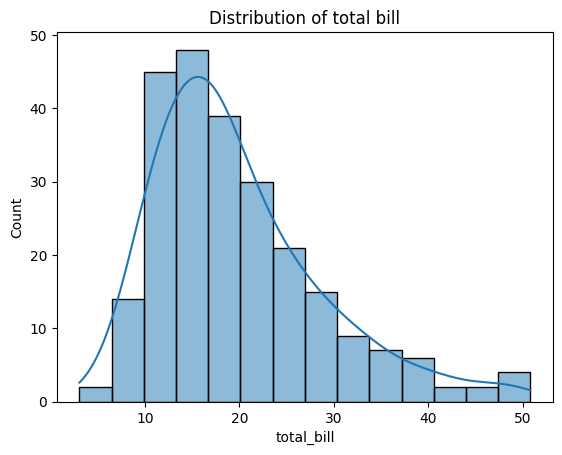

In [8]:
#url = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/tips.csv"

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

#load dataset
url = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/tips.csv"
df = pd.read_csv(url)
#inspect data
print(df.info())
print(df.describe())
del df["sex"]
del df["smoker"]
del df["day"]
del df["time"]
#visualize distributions
sns.histplot(df["total_bill"], kde = True)
plt.title("Distribution of total bill")
plt.show()

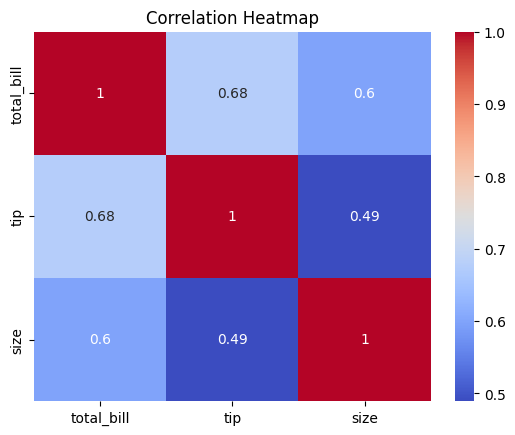

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

CONDUCTING HYPOTHESIS TESTING
STEPS
formulate null and alternative hypotheses
choose and perform an appropriate hypothesis test
interpret p_values and test results

In [15]:
from scipy.stats import ttest_ind

url = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/tips.csv"
df = pd.read_csv(url)

# seperate data by gender
male_tips = df[df['sex']=='Male']['tip']
female_tips = df[df['sex']=='Female']['tip']

#perform t-test

t_stat, p_value = ttest_ind(male_tips , female_tips)
print("T-statistic:" , t_stat)
print("P_values", p_value)

#interpret results
alpha = 0.05
if p_value <= alpha:
    print("Reject all null hypothesis: Significant difference")
else:
    print("Failed to reject all null hypothesis: No Significant difference")

T-statistic: 1.387859705421269
P_values 0.16645623503456755
Failed to reject all null hypothesis: No Significant difference


APPLYING LINEAR REGRESSION
STEPS 
  select dependent and independent variables
  fit a regression model to the data
  interpret coefficients and the R-squared value

Slope: 0.10502451738435337
Intercept: 0.9202696135546731
R-Squared: 0.45661658635167657


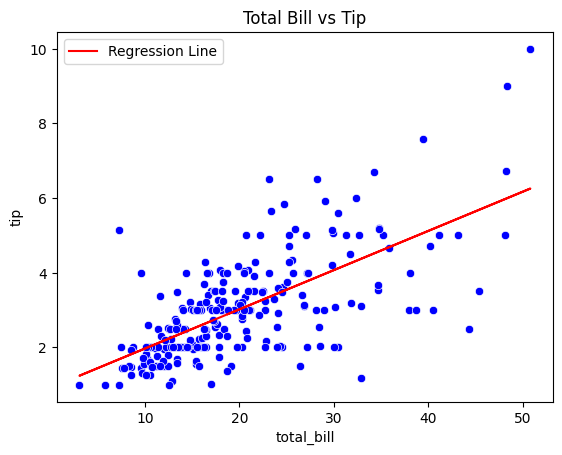

In [21]:
from sklearn.linear_model import LinearRegression
import numpy as np

#define variables
x = df['total_bill'].values.reshape(-1,1)
y = df['tip'].values

#fit linear regression
model = LinearRegression()
model.fit(x,y)

#output coefficients 
print("Slope:", model.coef_[0])
print("Intercept:", model.intercept_)
print("R-Squared:", model.score(x,y))

#plot regression
sns.scatterplot(x =df['total_bill'], y =df['tip'], color ="blue")
plt.plot(df['total_bill'], model.predict(x), color="red", label ="Regression Line")
plt.title("Total Bill vs Tip")
plt.legend()
plt.show()

HANDS ON PROJECT
STATISTICAL ANALYSIS OF REAL WORLD DATA
  - perform EDA
  - conduct hypothesis tests
  - apply linear regression

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   total_bill  244 non-null    float64
 1   tip         244 non-null    float64
 2   sex         244 non-null    object 
 3   smoker      244 non-null    object 
 4   day         244 non-null    object 
 5   time        244 non-null    object 
 6   size        244 non-null    int64  
dtypes: float64(2), int64(1), object(4)
memory usage: 13.5+ KB
None
       total_bill         tip        size
count  244.000000  244.000000  244.000000
mean    19.785943    2.998279    2.569672
std      8.902412    1.383638    0.951100
min      3.070000    1.000000    1.000000
25%     13.347500    2.000000    2.000000
50%     17.795000    2.900000    2.000000
75%     24.127500    3.562500    3.000000
max     50.810000   10.000000    6.000000


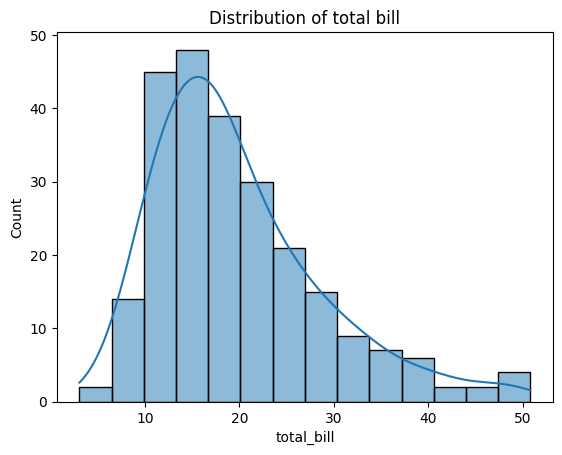

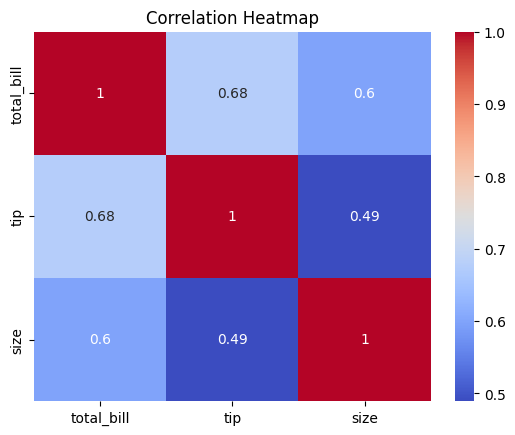

In [23]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

#load data
#load dataset
url = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/tips.csv"
df = pd.read_csv(url)
#inspect data
print(df.info())
print(df.describe())
del df["sex"]
del df["smoker"]
del df["day"]
del df["time"]
#visualize distributions
sns.histplot(df["total_bill"], kde = True)
plt.title("Distribution of total bill")
plt.show()

sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()


In [24]:
from scipy.stats import chi2_contingency

url = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/tips.csv"
df = pd.read_csv(url)
contingency_table = pd.crosstab(df['smoker'],df['time'])

#perfrom chi-squared test
chi2 , p , dof , expected = chi2_contingency(contingency_table)
print("Chi-Squared Statistics:", chi2)
print("P_values", p)

#interpret result
alpha = 0.05
if p<= alpha:
    print("Reject the null hypothesis: variables are dependent")
else:
    print("Fail to reject the null hypothesis variables are independent")

Chi-Squared Statistics: 0.5053733928754354
P_values 0.4771485672079724
Fail to reject the null hypothesis variables are independent


Slope: 0.10502451738435337
Intercept: 0.9202696135546731
R-Squared: 0.45661658635167657


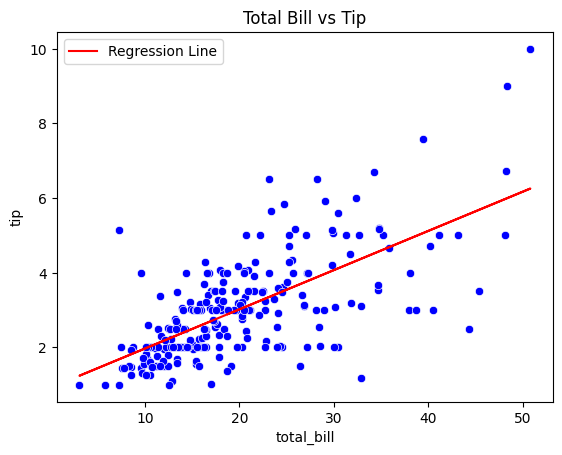

In [25]:
x = df['total_bill'].values.reshape(-1,1)
y = df['tip'].values

#fit linear regression
model = LinearRegression()
model.fit(x,y)

#output coefficients 
print("Slope:", model.coef_[0])
print("Intercept:", model.intercept_)
print("R-Squared:", model.score(x,y))

#plot regression
sns.scatterplot(x =df['total_bill'], y =df['tip'], color ="blue")
plt.plot(df['total_bill'], model.predict(x), color="red", label ="Regression Line")
plt.title("Total Bill vs Tip")
plt.legend()
plt.show()